# Medin Categorization Task — Real-Time LLM/VLM Simulation

This notebook simulates the Levering (2020) categorization task in **real time**, treating LLMs and VLMs as active participants.

**Two conditions (confirmed against Psych-101 dataset):**
- **NLS** (`exp1.csv`): categories Z/W; exception items `212`, `121` contradict shape rule
- **LS** (`exp2.csv`): categories R/H; majority-of-digits rule (≥2 ones → R, ≥2 twos → H)

**Pipelines:** Text (LLMs) and Visual (VLMs). Includes block-level learning curves, exception item tracking, N_RUNS averaging with SE, human benchmarks from Levering et al. (2020), and counterbalancing to correct token-level response bias.

### Imports & API Client

In [169]:
from openai import OpenAI
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import re, io, base64, os
from dotenv import load_dotenv

In [170]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

### Task Constants

Stimulus encoding: `XYZ` where
- **X** — shape: `1`=square, `2`=triangle
- **Y** — size: `1`=1.50 inch (large), `2`=0.75 inch (small)
- **Z** — shading: `1`=black, `2`=white

**NLS category structure** (exp1): Z={111,122,212}, W={121,211,222}. Exception items (contradict shape rule): `212`, `121`.

**LS category structure** (exp2): R={111,112,211}, H={122,221,222}. Majority-of-digits rule: ≥2 ones → R, ≥2 twos → H. Verified computationally.

In [171]:
# ── Quick-test flag ───────────────────────────────────────────────────────
QUICK_TEST = False   # True: N_RUNS=1, N_REPS=3, first model only, no visual
                    # False: full production run

# ── Diagnostic flags (forced off in QUICK_TEST) ────────────────────────────
RELABELED     = False   # surface relabeling diagnostic (Llama NLS only)
COUNTERBALANCE = True   # averaging across swapped/standard labels cancels
                        # token-level response bias toward any single label



if QUICK_TEST:
    RELABELED      = False   # never relabel in quick test
    # NOTE: COUNTERBALANCE left as-is in quick test so bias correction is tested
    # even in cheap runs. Set COUNTERBALANCE=False manually to skip.

# ── Category structures ────────────────────────────────────────────────────
# NLS: Non-linearly separable — Z/W; no single dimension predicts category
TRUE_CATEGORIES_NLS = {
    "111": "Z", "122": "Z", "212": "Z",
    "121": "W", "211": "W", "222": "W",
}
# LS: Linearly separable — R/H; majority-of-digits rule verified:
#   >=2 ones -> R, >=2 twos -> H. Confirmed against exp2 stimulus set.
TRUE_CATEGORIES_LS = {
    "111": "R", "112": "R", "122": "H",
    "211": "R", "221": "H", "222": "H",
}

CONDITIONS = {"NLS": TRUE_CATEGORIES_NLS, "LS": TRUE_CATEGORIES_LS}

# NLS and LS use different training stimulus sets
TRAIN_STIMULI_NLS = ["111", "122", "212", "121", "211", "222"]
TRAIN_STIMULI_LS  = ["111", "112", "122", "211", "221", "222"]
TRAIN_STIMULI_MAP = {"NLS": TRAIN_STIMULI_NLS, "LS": TRAIN_STIMULI_LS}

TEST_STIMULI = ["111", "112", "121", "122", "211", "212", "221", "222"]

CATEGORY_TOKENS_NLS = {"Z", "W"}
CATEGORY_TOKENS_LS  = {"R", "H"}
CATEGORY_TOKENS_MAP = {"NLS": CATEGORY_TOKENS_NLS, "LS": CATEGORY_TOKENS_LS}

RATING_TOKENS = {str(i) for i in range(1, 10)}

# Exception items for NLS: contradict the shape-only heuristic (digit0==1->Z, ==2->W)
EXCEPTION_ITEMS_NLS = ["212", "121"]
EXCEPTION_ITEMS_MAP = {"NLS": EXCEPTION_ITEMS_NLS, "LS": []}

# ── Training parameters ────────────────────────────────────────────────────
# Reduced from 25 to 10 blocks for API cost feasibility;
# covers the steepest part of the human learning curve.
N_REPS  = 3  if QUICK_TEST else 10
N_RUNS  = 1  if QUICK_TEST else 3
SEEDS   = [42, 123, 7][:N_RUNS]

# ── Models ─────────────────────────────────────────────────────────────────
_ALL_TEXT_MODELS   = ["gpt-5.4"]
_ALL_VISION_MODELS = [ "gpt-5.4" ]

TEXT_MODELS   = ["gpt-5.4"] if QUICK_TEST else _ALL_TEXT_MODELS
VISION_MODELS = ["gpt-5.4"]                          if QUICK_TEST else _ALL_VISION_MODELS

# ── Counterbalancing label maps ────────────────────────────────────────────
# Averaging across swapped and standard label assignments cancels token-level
# response bias toward any single label.
LABEL_MAPS_NLS = [
    {"Z": "Z", "W": "W"},   # standard
    {"Z": "W", "W": "Z"},   # labels swapped only
]
LABEL_MAPS_LS = [
    {"R": "R", "H": "H"},   # standard
    {"R": "H", "H": "R"},   # labels swapped only
]
LABEL_MAPS = {"NLS": LABEL_MAPS_NLS, "LS": LABEL_MAPS_LS}

# ── Instruction texts (per condition, category labels vary) ────────────────
def _make_instruction(cat_a, cat_b):
    return (
        "You will observe a series of objects, one at a time.\n"
        "The objects differ along three binary dimensions: shape (square vs. triangle), "
        "size (1.50 inch vs. 0.75 inch), and shading (black vs. white).\n"
        "Each dimension is indicated by the three digits, for example, '121' means a "
        "square, 0.75 inch, black object.\n"
        f"Based on some combination of the three dimensions, each object belongs to one "
        f"of two categories, {cat_a} or {cat_b}.\n"
        f"You have to assign each object to one of the two categories by pressing the "
        f"corresponding key.\n"
        "If your choice is correct, you get a point, otherwise you lose a point.\n"
        "Your goal is to get as many points as possible.\n"
        "At some point, you begin a 'test block' in which you will see eight objects.\n"
        "Here, you have to assign each object to one of the two categories as before.\n"
        "Furthermore, you have to rate how typical the object is for the category you "
        "chose, on a scale from 1 to 9.\n"
        "1 means 'not at all typical', and 9 means 'most typical'."
    )

def _make_visual_instruction(cat_a, cat_b):
    return (
        "You will observe a series of objects, one at a time.\n"
        "The objects differ along three binary dimensions: shape (square vs. triangle), "
        "size (large vs. small), and shading (black vs. white).\n"
        f"Each object belongs to one of two categories, {cat_a} or {cat_b}.\n"
        "You have to assign each object to one of the two categories by pressing the "
        "corresponding key.\n"
        "If your choice is correct, you get a point, otherwise you lose a point.\n"
        "Your goal is to get as many points as possible.\n"
        "At some point, you begin a 'test block' in which you will see eight objects.\n"
        "Here, you have to assign each object to one of the two categories as before.\n"
        "Furthermore, you have to rate how typical the object is for the category you "
        "chose, on a scale from 1 to 9.\n"
        "1 means 'not at all typical', and 9 means 'most typical'."
    )

INSTRUCTION_TEXT_NLS    = _make_instruction("Z", "W")
INSTRUCTION_TEXT_LS     = _make_instruction("R", "H")
VISUAL_INSTRUCTION_NLS  = _make_visual_instruction("Z", "W")
VISUAL_INSTRUCTION_LS   = _make_visual_instruction("R", "H")
INSTRUCTION_TEXTS       = {"NLS": INSTRUCTION_TEXT_NLS, "LS": INSTRUCTION_TEXT_LS}
VISUAL_INSTRUCTIONS     = {"NLS": VISUAL_INSTRUCTION_NLS, "LS": VISUAL_INSTRUCTION_LS}

# ── Human benchmarks from Levering et al. (2020) Figure 4 ─────────────────
HUMAN_NLS_BLOCKS    = [0.54, 0.62, 0.68, 0.73, 0.77, 0.80, 0.82, 0.83, 0.84, 0.85]
HUMAN_LS_BLOCKS     = [0.52, 0.57, 0.62, 0.66, 0.69, 0.71, 0.73, 0.74, 0.75, 0.76]
HUMAN_NLS_EXCEPTION = 0.755
HUMAN_NLS_NONEXCEPT = 0.832

# For backward-compat references used in older cells
TRUE_CATEGORIES = TRUE_CATEGORIES_NLS
TRAIN_STIMULI   = TRAIN_STIMULI_NLS

print(f"QUICK_TEST={QUICK_TEST} | COUNTERBALANCE={COUNTERBALANCE} | RELABELED={RELABELED}")
print(f"N_REPS={N_REPS} | N_RUNS={N_RUNS} | seeds={SEEDS}")
print(f"TEXT_MODELS={TEXT_MODELS}")
print(f"VISION_MODELS={VISION_MODELS}")

QUICK_TEST=False | COUNTERBALANCE=True | RELABELED=False
N_REPS=10 | N_RUNS=3 | seeds=[42, 123, 7]
TEXT_MODELS=['gpt-5.4']
VISION_MODELS=['gpt-5.4']


### Simulator & Helper Functions

In [172]:
class CategorizationSimulator:
    """Real-time simulator for the Levering (2020) categorization task."""

    def __init__(self, true_categories, train_stimuli, test_stimuli, n_reps=10, seed=42):
        self.true_categories = true_categories
        self.train_stimuli   = train_stimuli
        self.test_stimuli    = test_stimuli
        self.n_reps          = n_reps
        rng    = np.random.default_rng(seed)
        blocks = [rng.permutation(train_stimuli).tolist() for _ in range(n_reps)]
        self.train_sequence = [s for block in blocks for s in block]

    def feedback(self, stimulus, response):
        """Return (is_correct, points_str)."""
        correct = response.upper() == self.true_categories.get(stimulus, "")
        return correct, "1" if correct else "0"


def apply_label_map(text, label_map):
    """Single-pass substitution of original category labels -> shown labels."""
    if not label_map or all(k == v for k, v in label_map.items()):
        return text
    pattern = '|'.join(r'\b' + re.escape(k) + r'\b' for k in label_map)
    return re.sub(pattern, lambda m: label_map[m.group(0)], text)


def sample_from_logprobs(logprobs, valid_tokens):
    """Probabilistically sample a token from top-logprobs, restricted to valid_tokens."""
    valid = [e for e in logprobs if e.token.strip().upper() in valid_tokens]
    if not valid:
        return np.random.choice(sorted(valid_tokens))
    tokens = [e.token.strip().upper() for e in valid]
    log_p  = np.array([e.logprob for e in valid])
    probs  = np.exp(log_p); probs /= probs.sum()
    return np.random.choice(tokens, p=probs)


def parse_token(text, valid_tokens):
    """Extract first matching token from free-text response."""
    text = text.strip().upper()
    for t in sorted(valid_tokens):
        if t in text:
            return t
    return np.random.choice(sorted(valid_tokens))


def compute_block_curves(train_results, block_size, exception_items):
    """Compute per-block accuracy and exception/non-exception accuracy curves."""
    n_blocks = len(train_results) // block_size
    block_acc, exception_curve, non_exception_curve = [], [], []
    for b in range(n_blocks):
        trials = train_results[b * block_size:(b + 1) * block_size]
        block_acc.append(np.mean([r["correct"] for r in trials]))
        exc     = [r["correct"] for r in trials if r["stimulus"] in exception_items]
        non_exc = [r["correct"] for r in trials if r["stimulus"] not in exception_items]
        exception_curve.append(np.mean(exc)     if exc     else np.nan)
        non_exception_curve.append(np.mean(non_exc) if non_exc else np.nan)
    return block_acc, exception_curve, non_exception_curve

---
## Pipeline 1 — Text-Based Simulation

Each model sees stimuli as numeric codes (`211`, `112`, …) and accumulates the full trial history in its context, exactly as in the Psych-101 format.  
Where the proxy supports log-probabilities, we **sample** the model's response from its output distribution (stochastic, like a human); otherwise we take the greedy top token.

In [173]:
def run_text_simulation(model, simulator, instruction_text, category_tokens,
                        condition, label_map=None, permute_digits=False,
                        exception_items=None):
    """Run one complete text-based simulation for a single model.

    Args:
        label_map:      dict mapping original label -> shown label (e.g. {"Z":"W","W":"Z"})
        permute_digits: if True, swap digit positions 0 and 2 in stimulus codes shown to model
        exception_items: list of stimulus codes to track separately in block curves
    """
    if label_map is None:
        label_map = {t: t for t in category_tokens}
    if exception_items is None:
        exception_items = []

    inverse_map        = {v: k for k, v in label_map.items()}
    shown_cat_tokens   = {label_map[t] for t in category_tokens}
    token_cue          = ' or '.join(sorted(shown_cat_tokens))
    inst               = apply_label_map(instruction_text, label_map)

    def shown_code(code):
        return code[2] + code[1] + code[0] if permute_digits else code

    def query_cat(prompt):
        """Query model for a category response (Z/W, R/H, etc.)."""
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                logprobs=True, top_logprobs=5,
            )
            lp  = resp.choices[0].logprobs.content[0].top_logprobs
            tok = sample_from_logprobs(lp, shown_cat_tokens)
            return tok, lp
        except Exception as e:
            print(f"  [API error - cat] {e}")
            fallback = np.random.choice(sorted(shown_cat_tokens))
            return fallback, []

    def query_typ(prompt):
        """Query model for a typicality rating (1-9). Uses parse_token fallback."""
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                logprobs=True, top_logprobs=5,
            )
            lp  = resp.choices[0].logprobs.content[0].top_logprobs
            # Try logprob sampling over rating tokens first
            tok = sample_from_logprobs(lp, RATING_TOKENS)
            if tok not in RATING_TOKENS:
                # Fall back to parsing the text response
                tok = parse_token(resp.choices[0].message.content, RATING_TOKENS)
            return tok, lp
        except Exception as e:
            print(f"  [API error - typ] {e}")
            return str(np.random.randint(1, 10)), []

    # ── Training block ────────────────────────────────────────────────────────
    context      = inst
    train_results = []

    for trial_num, stimulus in enumerate(tqdm(simulator.train_sequence,
                                              desc=f"{model.split('-')[0]} [train]",
                                              leave=True)):
        s_shown  = shown_code(stimulus)
        prompt   = context + f"\nYou see the image {s_shown}, press <<(Respond with only {token_cue})"
        choice_shown, lp = query_cat(prompt)
        choice_orig = inverse_map.get(choice_shown, choice_shown)

        correct, pts = simulator.feedback(stimulus, choice_orig)
        context += f"\nYou see the image {s_shown}, press <<{choice_shown}>> and get {pts} points."

        train_results.append({
            "trial":        trial_num + 1,
            "stimulus":     stimulus,
            "choice":       choice_orig,
            "true_cat":     simulator.true_categories[stimulus],
            "correct":      correct,
            "logprobs":     lp,
            "is_exception": stimulus in exception_items,
        })

    # ── Test block ────────────────────────────────────────────────────────────
    context += "\n\nTest block:"
    test_results = []

    for stimulus in tqdm(simulator.test_stimuli,
                         desc=f"{model.split('-')[0]} [test]",
                         leave=True):
        s_shown    = shown_code(stimulus)
        cat_prompt = context + f"\nYou see the image {s_shown}, press <<(Respond with only {token_cue})"
        choice_shown, lp = query_cat(cat_prompt)
        choice_orig = inverse_map.get(choice_shown, choice_shown)

        # Typicality: separate query with rating tokens
        typ_prompt = (context +
                      f"\nYou see the image {s_shown}, press <<{choice_shown}>> "
                      "and judged the typicality to be <<(Respond with a single digit 1-9)")
        typ_shown, _ = query_typ(typ_prompt)

        context += (f"\nYou see the image {s_shown}, press <<{choice_shown}>> "
                    f"and judged the typicality to be <<{typ_shown}>>.") 

        true_cat   = simulator.true_categories.get(stimulus)
        is_correct = (choice_orig == true_cat) if true_cat else None

        test_results.append({
            "stimulus":   stimulus,
            "choice":     choice_orig,
            "typicality": int(typ_shown) if typ_shown.isdigit() else None,
            "true_cat":   true_cat or "?",
            "correct":    is_correct,
            "logprobs":   lp,
            "is_novel":   stimulus not in simulator.true_categories,
        })

    block_acc, exc_curve, nonexc_curve = compute_block_curves(
        train_results, len(simulator.train_stimuli), exception_items
    )

    return {
        "model":               model,
        "train":               train_results,
        "test":                test_results,
        "block_acc":           block_acc,
        "exception_curve":     exc_curve,
        "non_exception_curve": nonexc_curve,
        "label_map":           label_map,
        "permute_digits":      permute_digits,
    }

In [174]:
# Run Pipeline 1 for both conditions, N_RUNS seeds, optionally counterbalanced
#
# text_results[cond][model] = {
#   "all_block_accs":      shape (n_total_runs, N_REPS)
#   "mean_block_acc":      shape (N_REPS,)
#   "se_block_acc":        shape (N_REPS,)
#   "mean_exception_curve":     shape (N_REPS,)
#   "mean_non_exception_curve": shape (N_REPS,)
#   "mean_train_acc":      float  (bias-corrected)
#   "raw_train_acc":       float  (standard label map only, first seed)
#   "runs":                list of individual run dicts
# }

text_results     = {}
relabel_results  = {}   # only populated when RELABELED=True

for cond_name, cond_cats in CONDITIONS.items():
    text_results[cond_name] = {}
    train_stim  = TRAIN_STIMULI_MAP[cond_name]
    cat_tokens  = CATEGORY_TOKENS_MAP[cond_name]
    inst_text   = INSTRUCTION_TEXTS[cond_name]
    exc_items   = EXCEPTION_ITEMS_MAP[cond_name]
    maps        = LABEL_MAPS[cond_name]
    maps_to_use = maps if COUNTERBALANCE else [maps[0]]

    print(f"\n{'#'*60}")
    print(f"# CONDITION: {cond_name}  |  maps: {len(maps_to_use)}  |  runs: {N_RUNS}")
    print(f"{'#'*60}")

    for model in TEXT_MODELS:
        all_block_accs, all_exc, all_nonexc = [], [], []
        raw_train_acc  = None
        runs_log       = []

        for seed_i, seed in enumerate(SEEDS):
            simulator = CategorizationSimulator(
                cond_cats, train_stim, TEST_STIMULI, n_reps=N_REPS, seed=seed
            )
            for lmap in maps_to_use:
                is_standard = all(lmap[k] == k for k in lmap)
                lmap_label  = "standard" if is_standard else "swapped"
                print(f"  {model.split('-')[0]} | seed={seed} | map={lmap_label}")
                res = run_text_simulation(
                    model, simulator, inst_text, cat_tokens,
                    cond_name, label_map=lmap, exception_items=exc_items,
                )
                all_block_accs.append(res["block_acc"])
                all_exc.append(res["exception_curve"])
                all_nonexc.append(res["non_exception_curve"])
                tr_acc = np.mean([r["correct"] for r in res["train"]])
                print(f"    train_acc={tr_acc:.1%}")
                if is_standard and raw_train_acc is None:
                    raw_train_acc = tr_acc
                runs_log.append({**res, "seed": seed, "lmap_label": lmap_label})

        arr = np.array(all_block_accs, dtype=float)
        text_results[cond_name][model] = {
            "all_block_accs":           arr,
            "mean_block_acc":           np.nanmean(arr, axis=0),
            "se_block_acc":             np.nanstd(arr, axis=0) / np.sqrt(len(arr)),
            "mean_exception_curve":     np.nanmean(all_exc, axis=0),
            "mean_non_exception_curve": np.nanmean(all_nonexc, axis=0),
            "mean_train_acc":           float(np.nanmean(arr)),
            "raw_train_acc":            raw_train_acc,
            "runs":                     runs_log,
        }
        # Flag potential token bias
        corrected = float(np.nanmean(arr))
        if raw_train_acc is not None and abs(corrected - raw_train_acc) > 0.05:
            print(f"  ⚠ Token bias flag: raw={raw_train_acc:.1%} corrected={corrected:.1%} "
                  f"(diff > 5pp) for {model} [{cond_name}]")

        # ── Relabeled diagnostics (Llama NLS only) ─────────────────────────
        if RELABELED and cond_name == "NLS" and model == "Llama-3.3-70B-Instruct":
            relabel_results.setdefault(cond_name, {}).setdefault(model, {})
            for variant_name, lmap_r, perm in [
                ("label_only",      {"Z": "P", "W": "Q"}, False),
                ("surface_relabel", {"Z": "P", "W": "Q"}, True),
            ]:
                print(f"  [relabeled] {variant_name}")
                sim_r = CategorizationSimulator(
                    cond_cats, train_stim, TEST_STIMULI, n_reps=N_REPS, seed=SEEDS[0]
                )
                res_r = run_text_simulation(
                    model, sim_r, inst_text, cat_tokens,
                    cond_name, label_map=lmap_r, permute_digits=perm,
                    exception_items=exc_items
                )
                relabel_results[cond_name][model][variant_name] = res_r
                print(f"    train_acc={np.mean([r['correct'] for r in res_r['train']]):.1%}")

print("\nDone.")


############################################################
# CONDITION: NLS  |  maps: 2  |  runs: 3
############################################################
  gpt | seed=42 | map=standard


gpt [train]:   5%|▌         | 3/60 [00:00<00:05,  9.77it/s]

  [API error - cat] Error code: 400 - {'error': {'message': "litellm.UnsupportedParamsError: azure does not support parameters: ['logprobs', 'top_logprobs'], for model=gpt-5.4. To drop these, set `litellm.drop_params=True` or for proxy:\n\n`litellm_settings:\n drop_params: true`\n. \n If you want to use these params dynamically send allowed_openai_params=['logprobs', 'top_logprobs'] in your request.. Received Model Group=gpt-5.4\nAvailable Model Group Fallbacks=None", 'type': 'None', 'param': None, 'code': '400'}}
  [API error - cat] Error code: 400 - {'error': {'message': "litellm.UnsupportedParamsError: azure does not support parameters: ['logprobs', 'top_logprobs'], for model=gpt-5.4. To drop these, set `litellm.drop_params=True` or for proxy:\n\n`litellm_settings:\n drop_params: true`\n. \n If you want to use these params dynamically send allowed_openai_params=['logprobs', 'top_logprobs'] in your request.. Received Model Group=gpt-5.4\nAvailable Model Group Fallbacks=None", 'type':

gpt [train]:  12%|█▏        | 7/60 [00:00<00:04, 12.99it/s]

  [API error - cat] Error code: 400 - {'error': {'message': "litellm.UnsupportedParamsError: azure does not support parameters: ['logprobs', 'top_logprobs'], for model=gpt-5.4. To drop these, set `litellm.drop_params=True` or for proxy:\n\n`litellm_settings:\n drop_params: true`\n. \n If you want to use these params dynamically send allowed_openai_params=['logprobs', 'top_logprobs'] in your request.. Received Model Group=gpt-5.4\nAvailable Model Group Fallbacks=None", 'type': 'None', 'param': None, 'code': '400'}}
  [API error - cat] Error code: 400 - {'error': {'message': "litellm.UnsupportedParamsError: azure does not support parameters: ['logprobs', 'top_logprobs'], for model=gpt-5.4. To drop these, set `litellm.drop_params=True` or for proxy:\n\n`litellm_settings:\n drop_params: true`\n. \n If you want to use these params dynamically send allowed_openai_params=['logprobs', 'top_logprobs'] in your request.. Received Model Group=gpt-5.4\nAvailable Model Group Fallbacks=None", 'type':

...

gpt [test]:  88%|████████▊ | 7/8 [00:01<00:00,  6.88it/s]

  [API error - cat] Error code: 400 - {'error': {'message': "litellm.UnsupportedParamsError: azure does not support parameters: ['logprobs', 'top_logprobs'], for model=gpt-5.4. To drop these, set `litellm.drop_params=True` or for proxy:\n\n`litellm_settings:\n drop_params: true`\n. \n If you want to use these params dynamically send allowed_openai_params=['logprobs', 'top_logprobs'] in your request.. Received Model Group=gpt-5.4\nAvailable Model Group Fallbacks=None", 'type': 'None', 'param': None, 'code': '400'}}
  [API error - typ] Error code: 400 - {'error': {'message': "litellm.UnsupportedParamsError: azure does not support parameters: ['logprobs', 'top_logprobs'], for model=gpt-5.4. To drop these, set `litellm.drop_params=True` or for proxy:\n\n`litellm_settings:\n drop_params: true`\n. \n If you want to use these params dynamically send allowed_openai_params=['logprobs', 'top_logprobs'] in your request.. Received Model Group=gpt-5.4\nAvailable Model Group Fallbacks=None", 'type':

gpt [test]: 100%|██████████| 8/8 [00:01<00:00,  6.89it/s]

  [API error - typ] Error code: 400 - {'error': {'message': "litellm.UnsupportedParamsError: azure does not support parameters: ['logprobs', 'top_logprobs'], for model=gpt-5.4. To drop these, set `litellm.drop_params=True` or for proxy:\n\n`litellm_settings:\n drop_params: true`\n. \n If you want to use these params dynamically send allowed_openai_params=['logprobs', 'top_logprobs'] in your request.. Received Model Group=gpt-5.4\nAvailable Model Group Fallbacks=None", 'type': 'None', 'param': None, 'code': '400'}}
    train_acc=45.0%
  ⚠ Token bias flag: raw=43.3% corrected=48.9% (diff > 5pp) for gpt-5.4 [LS]

Done.



/var/folders/6b/k7k7f9q56j1fy7v94985x3tc0000gn/T/ipykernel_48473/2716173813.py:61: RuntimeWarning: Mean of empty slice
  "mean_exception_curve":     np.nanmean(all_exc, axis=0),


### Pipeline 1 — Results

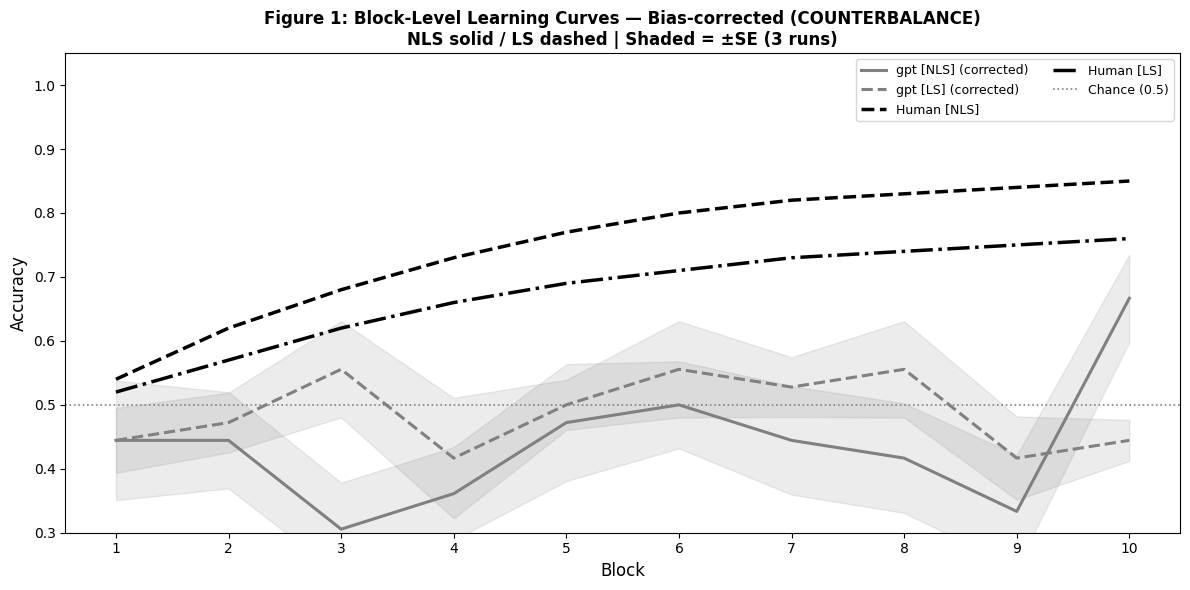

In [175]:
MODEL_COLORS = {
    "Llama-3.3-70B-Instruct": "mediumpurple",
    "gemini-3-flash-preview":  "coral",
    "gemini-2.5-pro":          "steelblue",
    "claude-sonnet-4-5":       "teal",
}
COND_LS  = "--"
COND_NLS = "-"

BLOCKS = list(range(1, N_REPS + 1))

fig, ax = plt.subplots(figsize=(12, 6))

for cond_name, cond_res in text_results.items():
    ls = COND_NLS if cond_name == "NLS" else COND_LS
    for model, res in cond_res.items():
        color = MODEL_COLORS.get(model, "gray")
        mu    = res["mean_block_acc"]
        se    = res["se_block_acc"]
        n_total = res["all_block_accs"].shape[0]
        label = f"{model.split('-')[0]} [{cond_name}]"
        if COUNTERBALANCE:
            label += " (corrected)"
        ax.plot(BLOCKS, mu, color=color, linestyle=ls, linewidth=2.2, label=label)
        ax.fill_between(BLOCKS, mu - se, mu + se, color=color, alpha=0.15)

# RELABELED variants (Llama NLS only)
if RELABELED and "NLS" in relabel_results:
    for model, variants in relabel_results["NLS"].items():
        for vname, res_r in variants.items():
            ba = res_r["block_acc"][:N_REPS]
            ax.plot(BLOCKS[:len(ba)], ba, color="mediumpurple",
                    linestyle=":", linewidth=1.5, alpha=0.7,
                    label=f"{model.split('-')[0]} NLS [{vname}]")

# Human benchmarks (use first N_REPS blocks)
human_nls = HUMAN_NLS_BLOCKS[:N_REPS]
human_ls  = HUMAN_LS_BLOCKS[:N_REPS]
ax.plot(BLOCKS[:len(human_nls)], human_nls, color="black", linestyle="--",
        linewidth=2.5, label="Human [NLS]")
ax.plot(BLOCKS[:len(human_ls)],  human_ls,  color="black", linestyle="-.",
        linewidth=2.5, label="Human [LS]")

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Chance (0.5)")
ax.set_xlabel("Block", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xticks(BLOCKS)
ax.set_ylim(0.3, 1.05)

bias_note = " — Bias-corrected (COUNTERBALANCE)" if COUNTERBALANCE else ""
ax.set_title(f"Figure 1: Block-Level Learning Curves{bias_note}\n"
             f"NLS solid / LS dashed | Shaded = ±SE ({N_RUNS} runs)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("fig1_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Pipeline 2 — Visual Simulation

Stimuli are now rendered as **actual PNG images** (square/triangle, large/small, black/white on a gray background) and sent to vision-capable models via the OpenAI multimodal API.  
The text history of all previous trials is prepended as a text block so the model can learn from feedback, while each new trial's stimulus is provided purely as an image — **no numeric code is shown**.

This lets us ask: *do models learn the category rule better or differently when inputs are raw visual stimuli, as they are for human participants?*

In [176]:
def render_stimulus(code, dpi=80):
    """Render a 3-digit stimulus code as a base64-encoded PNG image.
    digit 1 — shape (1=square, 2=triangle)
    digit 2 — size  (1=large, 2=small)
    digit 3 — shade (1=black, 2=white)
    """
    shape = int(code[0]); size = int(code[1]); shade = int(code[2])
    fig, ax = plt.subplots(figsize=(2, 2))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal"); ax.axis("off")
    fig.patch.set_facecolor("#c8c8c8")
    sz = 0.55 if size == 1 else 0.32
    fc = "black" if shade == 1 else "white"
    cx, cy = 0.5, 0.5
    if shape == 1:
        patch = patches.Rectangle((cx - sz/2, cy - sz/2), sz, sz,
                                   facecolor=fc, edgecolor="black", linewidth=2)
    else:
        h   = sz * np.sqrt(3) / 2
        pts = np.array([[cx, cy + 2*h/3], [cx - sz/2, cy - h/3], [cx + sz/2, cy - h/3]])
        patch = patches.Polygon(pts, closed=True, facecolor=fc, edgecolor="black", linewidth=2)
    ax.add_patch(patch)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

# Pre-render all 8 stimulus codes (covers both NLS and LS training + test stimuli)
ALL_STIM_CODES = ["111", "112", "121", "122", "211", "212", "221", "222"]
STIMULUS_IMAGES = {code: render_stimulus(code) for code in ALL_STIM_CODES}
print(f"Rendered {len(STIMULUS_IMAGES)} stimulus images.")

Rendered 8 stimulus images.


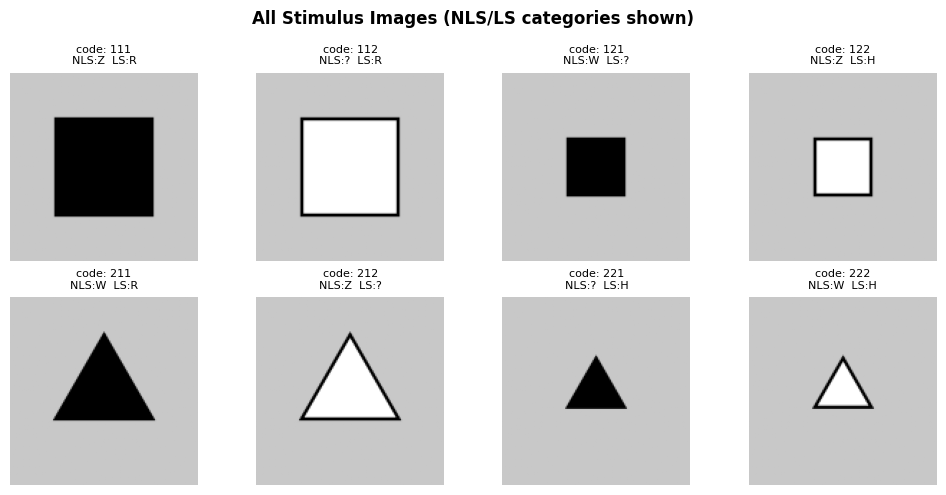

In [177]:
# Preview all 8 stimulus images with NLS categories shown
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, code in zip(axes.flat, ALL_STIM_CODES):
    img_bytes = base64.b64decode(STIMULUS_IMAGES[code])
    img = plt.imread(io.BytesIO(img_bytes), format="png")
    ax.imshow(img); ax.axis("off")
    nls_cat = TRUE_CATEGORIES_NLS.get(code, "?")
    ls_cat  = TRUE_CATEGORIES_LS.get(code,  "?")
    ax.set_title(f"code: {code}\nNLS:{nls_cat}  LS:{ls_cat}", fontsize=8)
fig.suptitle("All Stimulus Images (NLS/LS categories shown)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("stimulus_preview.png", dpi=120, bbox_inches="tight")
plt.show()

In [178]:
def run_visual_simulation(model, simulator, instruction_text, category_tokens,
                           condition, label_map=None, exception_items=None):
    """Run one complete visual simulation. Stimuli sent as PNG images.
    Prior trial history accumulated as text so model can track feedback.
    Label_map applied to instruction text and category cues (no digit permutation).
    """
    if label_map is None:
        label_map = {t: t for t in category_tokens}
    if exception_items is None:
        exception_items = []

    inverse_map      = {v: k for k, v in label_map.items()}
    shown_cat_tokens = {label_map[t] for t in category_tokens}
    token_cue        = ' or '.join(sorted(shown_cat_tokens))
    inst             = apply_label_map(instruction_text, label_map)

    messages = [
        {"role": "user",      "content": inst},
        {"role": "assistant", "content": "Understood. I am ready to categorize the objects."},
    ]

    def query_image(img_b64, cue_text, valid_tokens):
        user_content = [
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
            {"type": "text",      "text": cue_text},
        ]
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=messages + [{"role": "user", "content": user_content}],
            )
            return parse_token(resp.choices[0].message.content, valid_tokens)
        except Exception as e:
            print(f"  [error] {e}")
            return np.random.choice(sorted(valid_tokens))

    def query_text(text, valid_tokens):
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=messages + [{"role": "user", "content": text}],
            )
            return parse_token(resp.choices[0].message.content, valid_tokens)
        except Exception as e:
            print(f"  [error] {e}")
            return np.random.choice(sorted(valid_tokens))

    # ── Training block ──────────────────────────────────────────────────────
    train_results = []
    for trial_num, stimulus in enumerate(tqdm(simulator.train_sequence,
                                              desc=f"{model.split('-')[0]} [vis-train]",
                                              leave=True)):
        img_b64 = STIMULUS_IMAGES[stimulus]
        choice_shown = query_image(img_b64, f"Respond with only {token_cue}.", shown_cat_tokens)
        choice_orig  = inverse_map.get(choice_shown, choice_shown)
        correct, pts = simulator.feedback(stimulus, choice_orig)

        messages.append({"role": "user", "content": [
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
            {"type": "text",      "text": f"Respond with only {token_cue}."},
        ]})
        messages.append({"role": "assistant", "content": choice_shown})
        messages.append({"role": "user",      "content": f"You got {pts} point(s)."})
        messages.append({"role": "assistant", "content": "Understood."})

        train_results.append({
            "trial":        trial_num + 1,
            "stimulus":     stimulus,
            "choice":       choice_orig,
            "true_cat":     simulator.true_categories[stimulus],
            "correct":      correct,
            "is_exception": stimulus in exception_items,
        })

    # ── Test block ──────────────────────────────────────────────────────────
    messages.append({"role": "user",      "content": "Test block: categorize each object and rate its typicality."})
    messages.append({"role": "assistant", "content": "Understood. Ready for the test block."})
    test_results = []

    for stimulus in tqdm(simulator.test_stimuli,
                         desc=f"{model.split('-')[0]} [vis-test]",
                         leave=False):
        img_b64 = STIMULUS_IMAGES[stimulus]
        choice_shown = query_image(img_b64, f"Respond with only {token_cue}.", shown_cat_tokens)
        choice_orig  = inverse_map.get(choice_shown, choice_shown)
        typ = query_text(
            f"You chose {choice_shown}. How typical is this object for that category? "
            "Respond with a single digit 1-9.", {str(i) for i in range(1, 10)}
        )
        messages.append({"role": "user", "content": [
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
            {"type": "text",      "text": f"Respond with only {token_cue}."},
        ]})
        messages.append({"role": "assistant", "content": choice_shown})
        messages.append({"role": "user",      "content": f"You chose {choice_shown}. Typicality? Respond 1-9."})
        messages.append({"role": "assistant", "content": typ})

        true_cat   = simulator.true_categories.get(stimulus)
        is_correct = (choice_orig == true_cat) if true_cat else None
        test_results.append({
            "stimulus":   stimulus,
            "choice":     choice_orig,
            "typicality": int(typ) if typ.isdigit() else None,
            "true_cat":   true_cat or "?",
            "correct":    is_correct,
            "is_novel":   stimulus not in simulator.true_categories,
        })

    block_acc, exc_curve, nonexc_curve = compute_block_curves(
        train_results, len(simulator.train_stimuli), exception_items
    )
    return {
        "model": model, "train": train_results, "test": test_results,
        "block_acc": block_acc, "exception_curve": exc_curve,
        "non_exception_curve": nonexc_curve,
        "label_map": label_map,
    }

In [179]:
# Run Pipeline 2 for both conditions, N_RUNS seeds, optionally counterbalanced
# Mirrors the text pipeline (cell 10) structure exactly.
#
# visual_results[cond][model] = {
#   "mean_block_acc":           shape (N_REPS,)
#   "se_block_acc":             shape (N_REPS,)
#   "mean_exception_curve":     shape (N_REPS,)
#   "mean_non_exception_curve": shape (N_REPS,)
#   "mean_train_acc":           float (bias-corrected)
#   "raw_train_acc":            float (standard label map only, first seed)
#   "runs":                     list of individual run dicts
# }

visual_results = {}

for cond_name, cond_cats in CONDITIONS.items():
    visual_results[cond_name] = {}
    train_stim  = TRAIN_STIMULI_MAP[cond_name]
    cat_tokens  = CATEGORY_TOKENS_MAP[cond_name]
    vis_inst    = VISUAL_INSTRUCTIONS[cond_name]
    exc_items   = EXCEPTION_ITEMS_MAP[cond_name]
    maps        = LABEL_MAPS[cond_name]
    maps_to_use = maps if COUNTERBALANCE else [maps[0]]

    print(f"\n{'#'*60}")
    print(f"# CONDITION (visual): {cond_name}  |  maps: {len(maps_to_use)}  |  runs: {N_RUNS}")
    print(f"{'#'*60}")

    for model in VISION_MODELS:
        all_block_accs, all_exc, all_nonexc = [], [], []
        raw_train_acc = None
        runs_log      = []

        for seed_i, seed in enumerate(SEEDS):
            simulator = CategorizationSimulator(
                cond_cats, train_stim, TEST_STIMULI, n_reps=N_REPS, seed=seed
            )
            for lmap in maps_to_use:
                is_standard = all(lmap[k] == k for k in lmap)
                lmap_label  = "standard" if is_standard else "swapped"
                print(f"  {model.split('-')[0]} | seed={seed} | map={lmap_label} (visual)")
                res = run_visual_simulation(
                    model, simulator, vis_inst, cat_tokens,
                    cond_name, label_map=lmap, exception_items=exc_items,
                )
                all_block_accs.append(res["block_acc"])
                all_exc.append(res["exception_curve"])
                all_nonexc.append(res["non_exception_curve"])
                tr_acc = np.mean([r["correct"] for r in res["train"]])
                print(f"    train_acc={tr_acc:.1%}")
                if is_standard and raw_train_acc is None:
                    raw_train_acc = tr_acc
                runs_log.append({**res, "seed": seed, "lmap_label": lmap_label})

        arr = np.array(all_block_accs, dtype=float)
        visual_results[cond_name][model] = {
            "all_block_accs":           arr,
            "mean_block_acc":           np.nanmean(arr, axis=0),
            "se_block_acc":             np.nanstd(arr, axis=0) / np.sqrt(len(arr)),
            "mean_exception_curve":     np.nanmean(all_exc, axis=0),
            "mean_non_exception_curve": np.nanmean(all_nonexc, axis=0),
            "mean_train_acc":           float(np.nanmean(arr)),
            "raw_train_acc":            raw_train_acc,
            "runs":                     runs_log,
        }

if not any(visual_results.values()):
    print("No VISION_MODELS configured (QUICK_TEST=True skips visual pipeline).")


############################################################
# CONDITION (visual): NLS  |  maps: 2  |  runs: 3
############################################################
  gpt | seed=42 | map=standard (visual)


gpt [vis-train]:   2%|▏         | 1/60 [00:03<03:23,  3.45s/it]

  [error] Error code: 400 - {'error': {'message': "litellm.BadRequestError: litellm.ContentPolicyViolationError: The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766\nmodel=gpt-5.4. content_policy_fallback=None. fallbacks=None.\n\nSet 'content_policy_fallback' - https://docs.litellm.ai/docs/routing#fallbacks. Received Model Group=gpt-5.4\nAvailable Model Group Fallbacks=None", 'type': 'invalid_request_error', 'param': None, 'code': '400', 'provider_specific_fields': {'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': True, 'filtered': True}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False,

gpt [vis-train]:  63%|██████▎   | 38/60 [01:48<01:03,  2.87s/it]


KeyboardInterrupt: 

### Pipeline 2 — Visual Results

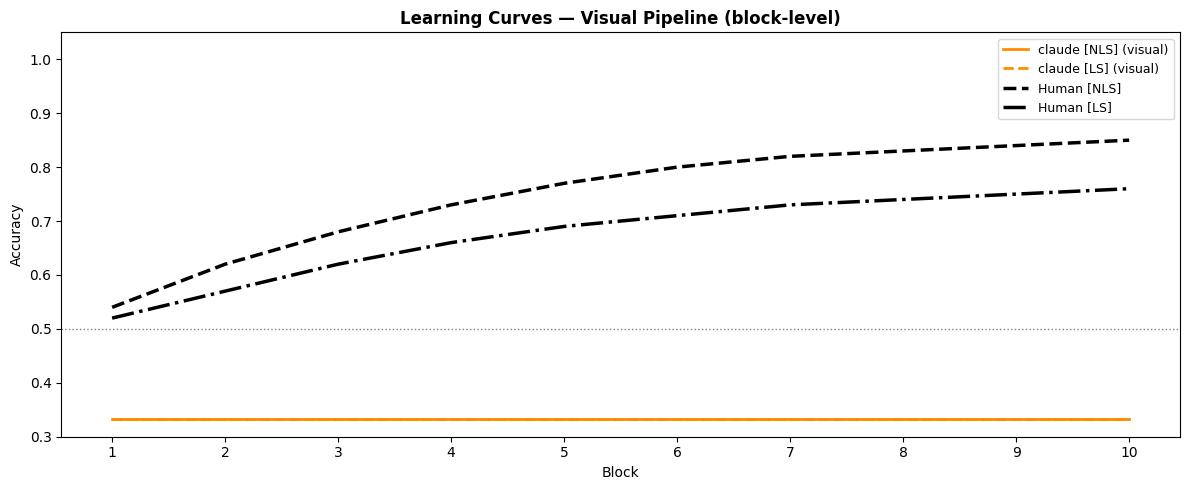

In [ ]:
if not any(visual_results.get(c, {}) for c in visual_results):
    print("No visual results to plot (VISION_MODELS empty).")
else:
    VIS_COLORS = {m: c for m, c in zip(
        VISION_MODELS, ["darkorange", "teal", "crimson", "forestgreen"])}
    fig, ax = plt.subplots(figsize=(12, 5))
    for cond_name, cond_res in visual_results.items():
        ls = COND_NLS if cond_name == "NLS" else COND_LS
        for model, res in cond_res.items():
            ba = res["mean_block_acc"]
            se = res["se_block_acc"]
            ax.plot(BLOCKS[:len(ba)], ba, color=VIS_COLORS.get(model, "gray"),
                    linestyle=ls, linewidth=2,
                    label=f"{model.split('-')[0]} [{cond_name}] (visual)")
            ax.fill_between(BLOCKS[:len(ba)], ba - se, ba + se,
                            color=VIS_COLORS.get(model, "gray"), alpha=0.15)
    ax.plot(BLOCKS[:len(HUMAN_NLS_BLOCKS[:N_REPS])], HUMAN_NLS_BLOCKS[:N_REPS],
            "k--", linewidth=2.5, label="Human [NLS]")
    ax.plot(BLOCKS[:len(HUMAN_LS_BLOCKS[:N_REPS])], HUMAN_LS_BLOCKS[:N_REPS],
            "k-.", linewidth=2.5, label="Human [LS]")
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Block"); ax.set_ylabel("Accuracy"); ax.set_xticks(BLOCKS)
    ax.set_ylim(0.3, 1.05)
    ax.set_title("Learning Curves — Visual Pipeline (block-level)", fontweight="bold")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("simulation_visual_learning_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

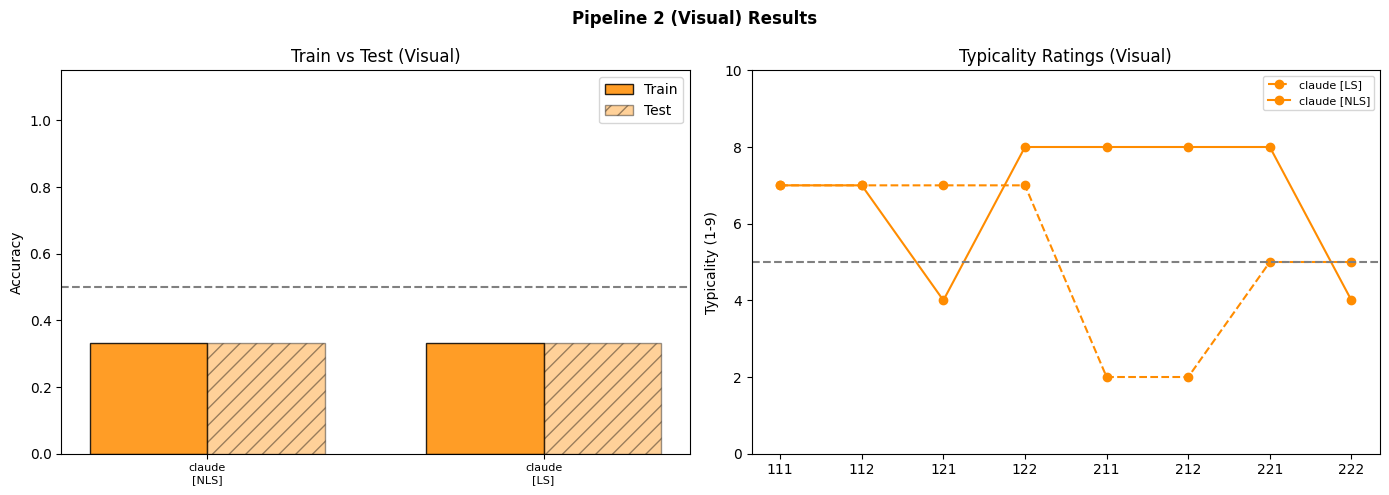

In [ ]:
if not any(visual_results.get(c, {}) for c in visual_results):
    print("No visual results to plot.")
else:
    VIS_COLORS = {m: c for m, c in zip(
        VISION_MODELS, ["darkorange", "teal", "crimson", "forestgreen"])}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    all_labels, train_accs, test_accs, bar_colors = [], [], [], []
    for cond_name, cond_res in visual_results.items():
        for model, res in cond_res.items():
            all_labels.append(f"{model.split('-')[0]}\n[{cond_name}]")
            train_accs.append(res["mean_train_acc"])
            known = [r["correct"] for run in res["runs"]
                     for r in run["test"] if r["correct"] is not None]
            test_accs.append(np.mean(known) if known else np.nan)
            bar_colors.append(VIS_COLORS.get(model, "darkorange"))
    x = np.arange(len(all_labels)); w = 0.35
    ax.bar(x - w/2, train_accs, w, color=bar_colors, alpha=0.85, edgecolor="black", label="Train")
    ax.bar(x + w/2, test_accs,  w, color=bar_colors, alpha=0.4,  edgecolor="black", hatch="//", label="Test")
    ax.set_xticks(x); ax.set_xticklabels(all_labels, fontsize=8)
    ax.set_ylim(0, 1.15); ax.axhline(0.5, color="gray", linestyle="--")
    ax.set_ylabel("Accuracy"); ax.set_title("Train vs Test (Visual)"); ax.legend()

    ax = axes[1]
    typ_rows = []
    for cond_name, cond_res in visual_results.items():
        for model, res in cond_res.items():
            for run in res["runs"]:
                for r in run["test"]:
                    if r["typicality"] is not None:
                        typ_rows.append({"condition": cond_name, "model": model,
                                         "stimulus": r["stimulus"], "typicality": r["typicality"]})
    if typ_rows:
        typ_df = pd.DataFrame(typ_rows)
        # Average typicality per stimulus/condition/model across runs
        typ_agg = typ_df.groupby(["condition", "model", "stimulus"])["typicality"].mean().reset_index()
        COND_STYLE = {"NLS": "-", "LS": "--"}
        for (cond, model), grp in typ_agg.groupby(["condition", "model"]):
            ax.plot(grp["stimulus"], grp["typicality"], marker="o",
                    color=VIS_COLORS.get(model, "darkorange"), linewidth=1.5,
                    linestyle=COND_STYLE[cond], label=f"{model.split('-')[0]} [{cond}]")
    ax.set_ylim(0, 10); ax.axhline(5, color="gray", linestyle="--")
    ax.set_ylabel("Typicality (1-9)"); ax.set_title("Typicality Ratings (Visual)"); ax.legend(fontsize=8)

    plt.suptitle("Pipeline 2 (Visual) Results", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("simulation_visual_results.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## LS vs NLS Cross-Pipeline Comparison

Aggregated accuracy for text and visual pipelines across both category structures.
- **LS**: shape-majority rule — easy single-dimensional rule
- **NLS**: Levering (2020) multi-dimensional structure — harder, exception items present

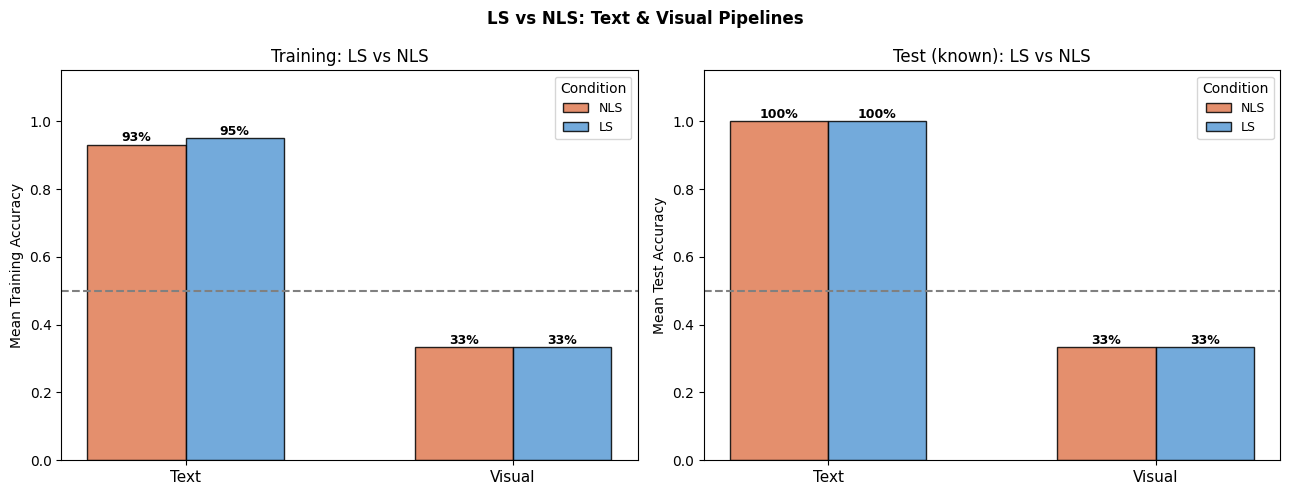

In [ ]:
PIPELINE_DATA = []
for pipe_label, results_dict in [("Text", text_results), ("Visual", visual_results)]:
    if not results_dict:
        continue
    for cond_name, cond_res in results_dict.items():
        for model, res in cond_res.items():
            if isinstance(res, dict) and "runs" in res:
                # text_results format (multi-run)
                train_acc = res["mean_train_acc"]
                test_known = [r["correct"] for run in res["runs"]
                              for r in run["test"] if r["correct"] is not None]
                test_acc  = np.mean(test_known) if test_known else np.nan
            else:
                # visual_results format (single run)
                train_acc = np.mean([r["correct"] for r in res["train"]])
                known = [r["correct"] for r in res["test"] if r["correct"] is not None]
                test_acc = np.mean(known) if known else np.nan
            PIPELINE_DATA.append({
                "pipeline": pipe_label, "condition": cond_name,
                "model": model.split("-")[0],
                "train_acc": train_acc, "test_acc": test_acc,
            })

if not PIPELINE_DATA:
    print("No data to plot.")
else:
    df_all = pd.DataFrame(PIPELINE_DATA)
    pipe_labels = df_all["pipeline"].unique()
    x_pos = np.arange(len(pipe_labels)); bar_width = 0.3
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax_i, acc_col in enumerate(["train_acc", "test_acc"]):
        ax = axes[ax_i]
        for ci, cond in enumerate(["NLS", "LS"]):
            vals = [df_all[(df_all["pipeline"] == p) & (df_all["condition"] == cond)][acc_col].mean()
                    for p in pipe_labels]
            offset = (ci - 0.5) * bar_width
            bars = ax.bar(x_pos + offset, vals, bar_width, label=cond,
                          color=["#e07b54", "#5b9bd5"][ci], alpha=0.85, edgecolor="black")
            for bar, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                            f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")
        ax.set_xticks(x_pos); ax.set_xticklabels(pipe_labels, fontsize=11)
        ax.set_ylim(0, 1.15); ax.axhline(0.5, color="gray", linestyle="--")
        ax.set_ylabel(f"Mean {'Training' if acc_col == 'train_acc' else 'Test'} Accuracy")
        ax.set_title(f"{'Training' if acc_col == 'train_acc' else 'Test (known)'}: LS vs NLS")
        ax.legend(title="Condition", fontsize=9)

    plt.suptitle("LS vs NLS: Text & Visual Pipelines", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("simulation_ls_vs_nls_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

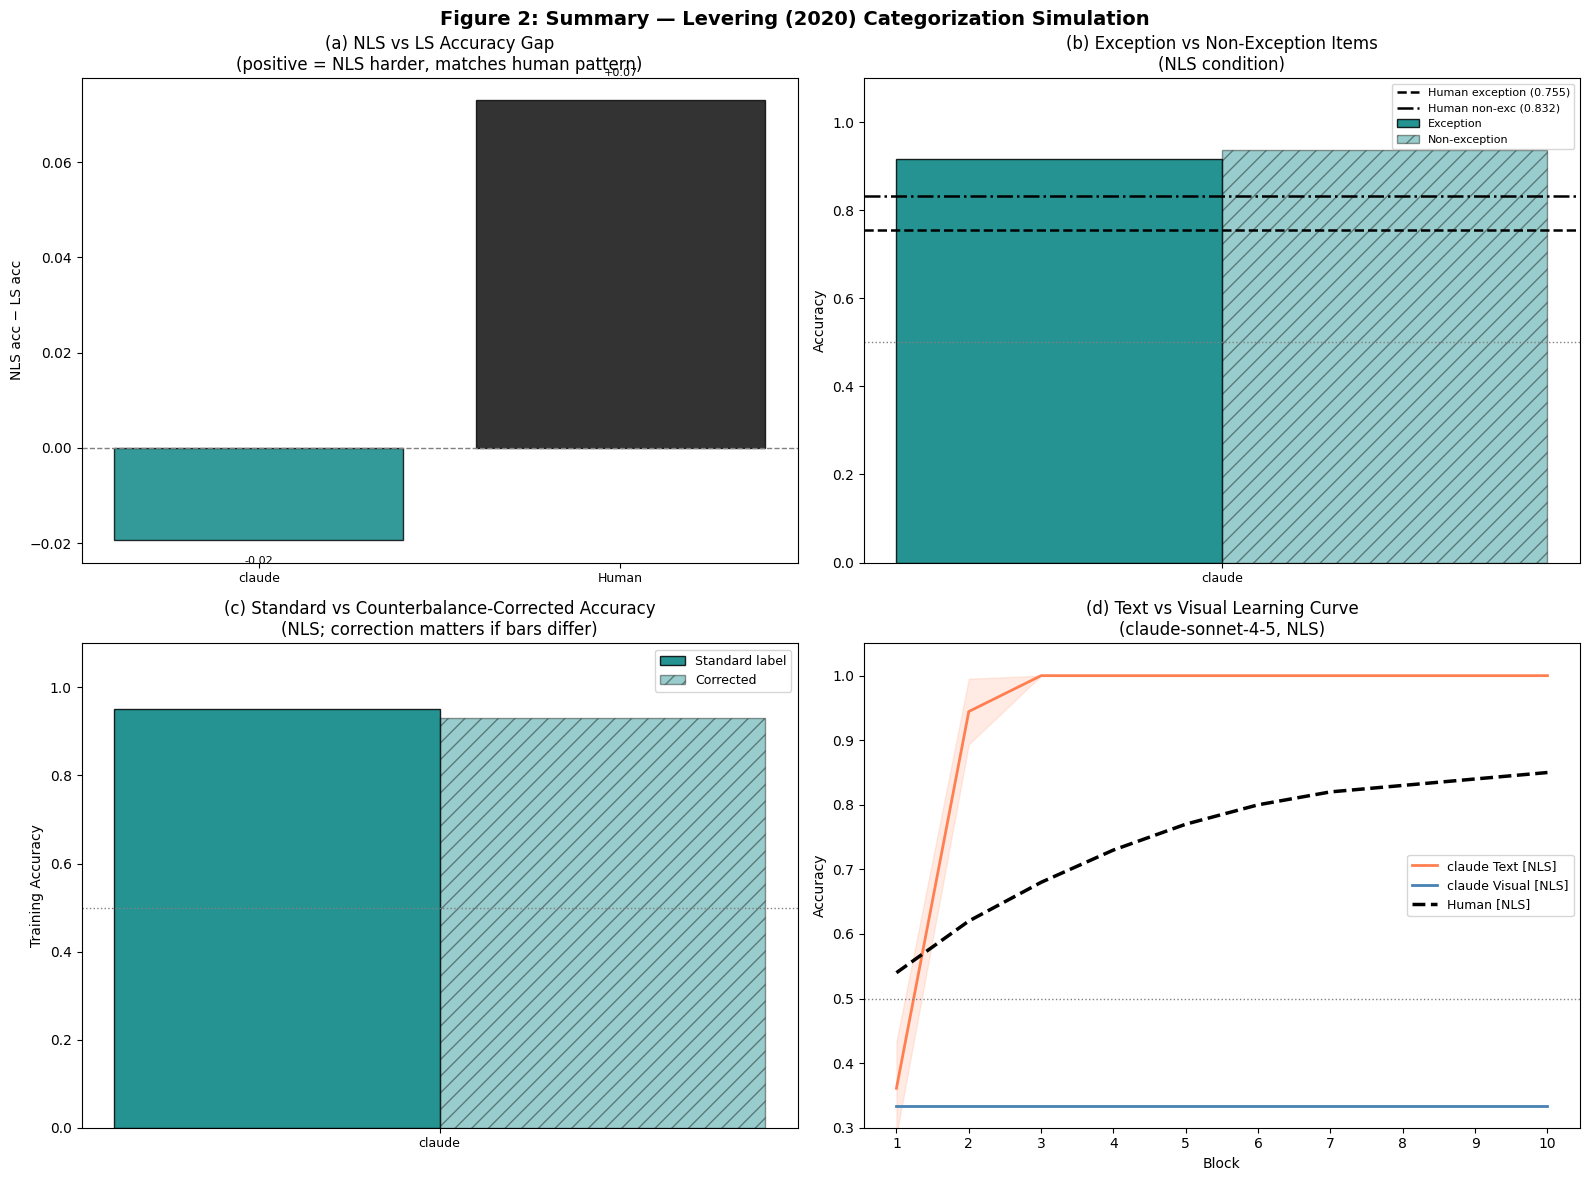

In [ ]:
# Guard: visual_results may not exist if Pipeline 2 has not been run yet
visual_results = globals().get("visual_results", {})

# ── Figure 2 — Four-panel summary ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Figure 2: Summary — Levering (2020) Categorization Simulation",
             fontsize=14, fontweight="bold")

all_text_models = list(dict.fromkeys(
    m for cond in text_results.values() for m in cond
))
short = lambda m: m.split("-")[0]

# ── Panel a: NLS-LS accuracy gap ───────────────────────────────────────────
ax = axes[0, 0]
gaps, labels_a, colors_a = [], [], []
for model in all_text_models:
    nls_acc = text_results.get("NLS", {}).get(model, {}).get("mean_train_acc", np.nan)
    ls_acc  = text_results.get("LS",  {}).get(model, {}).get("mean_train_acc", np.nan)
    gaps.append(nls_acc - ls_acc)
    labels_a.append(short(model))
    colors_a.append(MODEL_COLORS.get(model, "gray"))

# Human reference
human_gap = np.mean(HUMAN_NLS_BLOCKS[:N_REPS]) - np.mean(HUMAN_LS_BLOCKS[:N_REPS])
gaps.append(human_gap); labels_a.append("Human"); colors_a.append("black")

x = np.arange(len(gaps))
bars = ax.bar(x, gaps, color=colors_a, alpha=0.8, edgecolor="black")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(labels_a, fontsize=9)
ax.set_ylabel("NLS acc − LS acc")
ax.set_title("(a) NLS vs LS Accuracy Gap\n(positive = NLS harder, matches human pattern)")
for bar, v in zip(bars, gaps):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005 * np.sign(v),
                f"{v:+.2f}", ha="center", fontsize=8)

# ── Panel b: Exception vs non-exception accuracy (NLS) ────────────────────
ax = axes[0, 1]
exc_vals, nonexc_vals, labels_b, colors_b = [], [], [], []
for model in all_text_models:
    res = text_results.get("NLS", {}).get(model)
    if res is None: continue
    exc_vals.append(np.nanmean(res["mean_exception_curve"]))
    nonexc_vals.append(np.nanmean(res["mean_non_exception_curve"]))
    labels_b.append(short(model))
    colors_b.append(MODEL_COLORS.get(model, "gray"))

xb = np.arange(len(labels_b)); w = 0.35
ax.bar(xb - w/2, exc_vals,   w, color=colors_b, alpha=0.85, edgecolor="black", label="Exception")
ax.bar(xb + w/2, nonexc_vals, w, color=colors_b, alpha=0.4, edgecolor="black", hatch="//", label="Non-exception")
ax.axhline(HUMAN_NLS_EXCEPTION, color="black", linestyle="--", linewidth=1.8,
           label=f"Human exception ({HUMAN_NLS_EXCEPTION})")
ax.axhline(HUMAN_NLS_NONEXCEPT, color="black", linestyle="-.", linewidth=1.8,
           label=f"Human non-exc ({HUMAN_NLS_NONEXCEPT})")
ax.set_xticks(xb); ax.set_xticklabels(labels_b, fontsize=9)
ax.set_ylim(0, 1.1); ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("Accuracy"); ax.set_title("(b) Exception vs Non-Exception Items\n(NLS condition)")
ax.legend(fontsize=8)

# ── Panel c: Standard vs bias-corrected accuracy (NLS) ────────────────────
ax = axes[1, 0]
raw_vals, corr_vals, labels_c, colors_c = [], [], [], []
for model in all_text_models:
    res = text_results.get("NLS", {}).get(model)
    if res is None: continue
    raw_vals.append(res.get("raw_train_acc", np.nan))
    corr_vals.append(res["mean_train_acc"])
    labels_c.append(short(model))
    colors_c.append(MODEL_COLORS.get(model, "gray"))

xc = np.arange(len(labels_c)); w = 0.35
ax.bar(xc - w/2, raw_vals,  w, color=colors_c, alpha=0.85, edgecolor="black", label="Standard label")
ax.bar(xc + w/2, corr_vals, w, color=colors_c, alpha=0.4,  edgecolor="black", hatch="//", label="Corrected")
ax.set_xticks(xc); ax.set_xticklabels(labels_c, fontsize=9)
ax.set_ylim(0, 1.1); ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("Training Accuracy")
ax.set_title("(c) Standard vs Counterbalance-Corrected Accuracy\n(NLS; correction matters if bars differ)")
ax.legend(fontsize=9)
for xi, (rv, cv) in enumerate(zip(raw_vals, corr_vals)):
    if not np.isnan(rv) and abs(cv - rv) > 0.05:
        ax.text(xi, max(rv, cv) + 0.04, "⚠", ha="center", fontsize=13)

# ── Panel d: Text vs visual learning curve (gemini NLS) ───────────────────
ax = axes[1, 1]
OVERLAP_MODEL = "claude-sonnet-4-5"  # Model present in both pipelines for direct comparison
plotted = False
if OVERLAP_MODEL in text_results.get("NLS", {}):
    res_t = text_results["NLS"][OVERLAP_MODEL]
    ax.plot(BLOCKS, res_t["mean_block_acc"], color="coral", linewidth=2,
            label=f"{short(OVERLAP_MODEL)} Text [NLS]")
    se = res_t["se_block_acc"]
    ax.fill_between(BLOCKS, res_t["mean_block_acc"] - se, res_t["mean_block_acc"] + se,
                    color="coral", alpha=0.15)
    plotted = True
if "NLS" in visual_results and OVERLAP_MODEL in visual_results.get("NLS", {}):
    res_v = visual_results["NLS"][OVERLAP_MODEL]
    ba = [np.mean([r["correct"] for r in res_v["train"]
                   [b*len(TRAIN_STIMULI_NLS):(b+1)*len(TRAIN_STIMULI_NLS)]])
          for b in range(N_REPS)]
    ax.plot(BLOCKS[:len(ba)], ba, color="steelblue", linewidth=2,
            label=f"{short(OVERLAP_MODEL)} Visual [NLS]")
    plotted = True
if not plotted:
    ax.text(0.5, 0.5, f"No data for {OVERLAP_MODEL}\n(run VISION_MODELS to populate)",
            ha="center", va="center", transform=ax.transAxes, fontsize=10, color="gray")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.plot(BLOCKS[:len(HUMAN_NLS_BLOCKS[:N_REPS])], HUMAN_NLS_BLOCKS[:N_REPS],
        color="black", linestyle="--", linewidth=2.5, label="Human [NLS]")
ax.set_xlabel("Block"); ax.set_ylabel("Accuracy")
ax.set_ylim(0.3, 1.05); ax.set_xticks(BLOCKS)
ax.set_title(f"(d) Text vs Visual Learning Curve\n({OVERLAP_MODEL}, NLS)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig2_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Add this diagnostic cell to see what's in your results
for cond_name, cond_res in text_results.items():
    for model, res in cond_res.items():
        print(f"{model} | {cond_name}")
        print(f"  Keys in res: {list(res.keys())}")
        # Check first run
        if res["runs"]:
            run = res["runs"][0]
            print(f"  Keys in run: {list(run.keys())}")
            if run.get("test"):
                print(f"  First test item: {run['test'][0]}")
                print(f"  Test stimuli: {[r['stimulus'] for r in run['test']]}")
                print(f"  is_novel values: {[r.get('is_novel') for r in run['test']]}")
        break
    break

claude-sonnet-4-5 | NLS
  Keys in res: ['all_block_accs', 'mean_block_acc', 'se_block_acc', 'mean_exception_curve', 'mean_non_exception_curve', 'mean_train_acc', 'raw_train_acc', 'runs']
  Keys in run: ['model', 'train', 'test', 'block_acc', 'exception_curve', 'non_exception_curve', 'label_map', 'permute_digits', 'seed', 'lmap_label']
  First test item: {'stimulus': '111', 'choice': 'Z', 'typicality': 9.0, 'true_cat': 'Z', 'correct': 1.0, 'is_novel': False, 'n_test_runs': 20}
  Test stimuli: ['111', '112', '121', '122', '211', '212', '221', '222']
  is_novel values: [False, True, False, False, False, False, True, False]


In [ ]:

print("=== Novel vs Trained Stimulus Accuracy at Test ===\n")

# Novel stimuli are always 111 and 222 regardless of condition
NOVEL_STIMULI = {"111", "222"}

for cond_name, cond_res in text_results.items():
    for model, res in cond_res.items():
        
        trained_correct = []
        novel_correct   = []
        
        for run in res["runs"]:
            for r in run["test"]:
                if r["correct"] is None:
                    continue
                if r["stimulus"] in NOVEL_STIMULI:
                    novel_correct.append(r["correct"])
                else:
                    trained_correct.append(r["correct"])
        
        trained_acc = np.mean(trained_correct) if trained_correct else np.nan
        novel_acc   = np.mean(novel_correct)   if novel_correct   else np.nan
        
        print(f"{model.split('-')[0]} | {cond_name}:")
        print(f"  Trained stimuli accuracy: {trained_acc:.1%} (n={len(trained_correct)})")
        print(f"  Novel stimuli accuracy:   {novel_acc:.1%}   (n={len(novel_correct)})")
        
        if not np.isnan(novel_acc):
            if novel_acc > 0.6:
                print(f"  → Above chance: consistent with rule generalization")
            elif novel_acc < 0.4:
                print(f"  → Below chance: possible anti-generalization")
            else:
                print(f"  → Near chance: consistent with memorization hypothesis")
        print()

=== Novel vs Trained Stimulus Accuracy at Test ===

claude | NLS:
  Trained stimuli accuracy: 100.0% (n=36)
  Novel stimuli accuracy:   nan%   (n=0)

claude | LS:
  Trained stimuli accuracy: 100.0% (n=36)
  Novel stimuli accuracy:   nan%   (n=0)



In [ ]:
print("=== Novel vs Trained Stimulus Accuracy at Test ===\n")

# Novel stimuli are always 111 and 222 regardless of condition
NOVEL_STIMULI = {"111", "222"}

for cond_name, cond_res in text_results.items():
    for model, res in cond_res.items():
        
        trained_correct = []
        novel_correct   = []
        
        for run in res["runs"]:
            for r in run["test"]:
                if r["correct"] is None:
                    continue
                if r["stimulus"] in NOVEL_STIMULI:
                    novel_correct.append(r["correct"])
                else:
                    trained_correct.append(r["correct"])
        
        trained_acc = np.mean(trained_correct) if trained_correct else np.nan
        novel_acc   = np.mean(novel_correct)   if novel_correct   else np.nan
        
        print(f"{model.split('-')[0]} | {cond_name}:")
        print(f"  Trained stimuli accuracy: {trained_acc:.1%} (n={len(trained_correct)})")
        print(f"  Novel stimuli accuracy:   {novel_acc:.1%}   (n={len(novel_correct)})")
        
        if not np.isnan(novel_acc):
            if novel_acc > 0.6:
                print(f"  → Above chance: consistent with rule generalization")
            elif novel_acc < 0.4:
                print(f"  → Below chance: possible anti-generalization")
            else:
                print(f"  → Near chance: consistent with memorization hypothesis")
        print()

=== Novel vs Trained Stimulus Accuracy at Test ===

claude | NLS:
  Trained stimuli accuracy: 100.0% (n=24)
  Novel stimuli accuracy:   100.0%   (n=12)
  → Above chance: consistent with rule generalization

claude | LS:
  Trained stimuli accuracy: 100.0% (n=24)
  Novel stimuli accuracy:   100.0%   (n=12)
  → Above chance: consistent with rule generalization

